# Participation ratio across the neural timecourse

For each timepoint, this notebook treats trials/images as samples and channels as features, runs PCA on the target monkey neural response matrix, and plots the participation ratio of the PCA variance spectrum over time.

In [1]:
import os, sys, yaml
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parents[0] if cwd.name == "python_scripts" else cwd.parents[1]

with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)

paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from project_specific_utils.dataloader import load_img_natraster
from useful_stuff.general_utils.utils import TimeSeries

In [2]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str | None = "AIT"
    new_fs: int = 100
    baseline_window_ms: tuple[float, float] | None = None


cfg = Cfg()
cfg

Cfg(monkey_name='three0', date='250313', brain_area='AIT', new_fs=100, baseline_window_ms=None)

In [3]:
def slice_brain_area(rasters, monkey_name: str, brain_area: str | None):
    if brain_area is None:
        return rasters

    with open(PROJECT_ROOT / "brain_areas.yaml", "r") as f:
        brain_area_config = yaml.safe_load(f)

    area_limits = brain_area_config[monkey_name][brain_area]
    raster_arr = rasters.get_array()
    area_arr = np.concatenate([raster_arr[start:end, ...] for start, end in area_limits], axis=0)
    return TimeSeries(area_arr, rasters.get_fs())


full_rasters = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
)
rasters = slice_brain_area(full_rasters, cfg.monkey_name, cfg.brain_area)

raster_arr = rasters.get_array()
n_channels, n_timepoints, n_trials = raster_arr.shape
time_ms = np.arange(n_timepoints) / rasters.get_fs() * 1000

print(f"raster shape (channels, time, trials): {raster_arr.shape}")
print(f"sampling frequency: {rasters.get_fs()} Hz")
print(f"target: {cfg.monkey_name} {cfg.date} {cfg.brain_area}")

raster shape (channels, time, trials): (25, 30, 776)
sampling frequency: 100 Hz
target: three0 250313 AIT


In [4]:
def pca_variance_spectrum(X: np.ndarray) -> np.ndarray:
    """Return the PCA explained variance spectrum for samples x features data."""
    X = np.asarray(X, dtype=np.float64)
    X = X - X.mean(axis=0, keepdims=True)
    if X.shape[0] < 2:
        raise ValueError("PCA requires at least two samples/trials.")

    singular_values = np.linalg.svd(X, full_matrices=False, compute_uv=False)
    return singular_values**2 / (X.shape[0] - 1)


def participation_ratio(eigenvalues: np.ndarray) -> float:
    """Compute PR = (sum(lambda))^2 / sum(lambda^2)."""
    eigenvalues = np.asarray(eigenvalues, dtype=np.float64)
    denominator = np.sum(eigenvalues**2)
    if denominator == 0:
        return np.nan
    return np.sum(eigenvalues) ** 2 / denominator


def compute_pr_timecourse(raster_arr: np.ndarray) -> tuple[np.ndarray, list[np.ndarray]]:
    """Run PCA independently at every timepoint and return PR(t)."""
    spectra = []
    prs = np.empty(raster_arr.shape[1], dtype=np.float64)

    for t in range(raster_arr.shape[1]):
        X_t = raster_arr[:, t, :].T  # samples/trials x features/channels
        ev = pca_variance_spectrum(X_t)
        spectra.append(ev)
        prs[t] = participation_ratio(ev)

    return prs, spectra


pr_timecourse, pca_spectra = compute_pr_timecourse(raster_arr)

print(f"computed PCA for {len(pca_spectra)} timepoints")
print(f"PR range: {np.nanmin(pr_timecourse):.2f} to {np.nanmax(pr_timecourse):.2f}")

computed PCA for 30 timepoints
PR range: 14.61 to 21.71


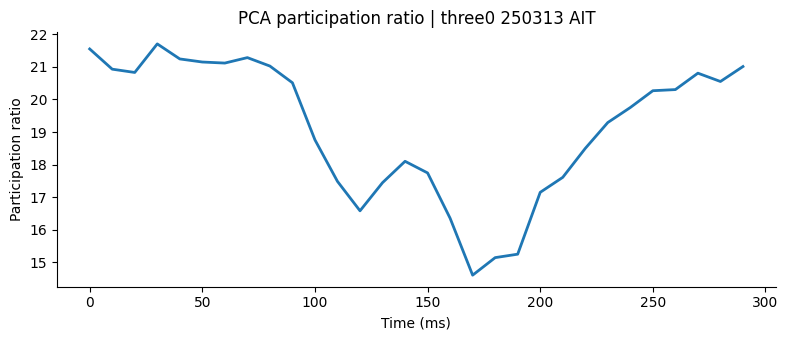

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(time_ms, pr_timecourse, linewidth=2, color="tab:blue")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Participation ratio")
ax.set_title(f"PCA participation ratio | {cfg.monkey_name} {cfg.date} {cfg.brain_area}")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [6]:
if cfg.baseline_window_ms is not None:
    t0, t1 = cfg.baseline_window_ms
    baseline_mask = (time_ms >= t0) & (time_ms < t1)
    if not np.any(baseline_mask):
        raise ValueError(f"No samples in baseline window {cfg.baseline_window_ms} ms.")

    pr_baseline = np.nanmean(pr_timecourse[baseline_mask])
    pr_delta = pr_timecourse - pr_baseline

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.axhline(0, color="0.3", linewidth=1, linestyle="--")
    ax.plot(time_ms, pr_delta, linewidth=2, color="tab:orange")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Participation ratio - baseline")
    ax.set_title(f"Baseline-corrected PR | baseline {t0:g}-{t1:g} ms")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
else:
    print("Set cfg.baseline_window_ms = (start_ms, end_ms) to plot a baseline-corrected PR trace.")

Set cfg.baseline_window_ms = (start_ms, end_ms) to plot a baseline-corrected PR trace.


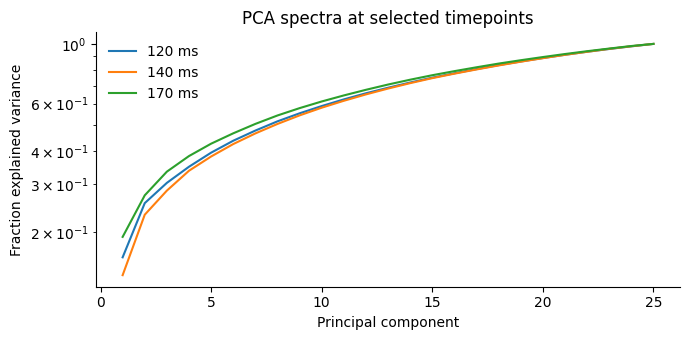

In [11]:
selected_timepoints_ms = [120, 140, 170] #time_ms[0], time_ms[len(time_ms) // 2], time_ms[-1]]

fig, ax = plt.subplots(figsize=(7, 3.5))
for t_ms in selected_timepoints_ms:
    idx = int(np.argmin(np.abs(time_ms - t_ms)))
    spectrum = pca_spectra[idx]
    normalized_spectrum = np.cumsum(spectrum) / np.sum(spectrum)
    ax.plot(
        np.arange(1, len(normalized_spectrum) + 1),
        normalized_spectrum,
        linewidth=1.5,
        label=f"{time_ms[idx]:.0f} ms",
    )

ax.set_xlabel("Principal component")
ax.set_ylabel("Fraction explained variance")
ax.set_yscale("log")
ax.set_title("PCA spectra at selected timepoints")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [9]:
selected_timepoints_ms

[np.float64(0.0), np.float64(150.0), np.float64(290.0)]